In this notebook, we clean the labeled data by removing unlabeled samples, low-speed segments, and high-yaw-rate (turning) segments.

**Input**: `data/interim/labeled/labeled_dataset.csv`  
**Output**: `data/interim/cleaned/cleaned_dataset.csv`  

The cleaned dataset keeps the derived columns `net_speed` and `yaw_rate` for downstream checks and windowing.

In [35]:
from pathlib import Path
import sys
import pandas as pd

# Make project root importable whether CWD is repo root or notebooks/
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'src').exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.labels import plot_labeled_sensors, plot_labeled_acc, plot_labeled_gyro, plot_labeled_odo

In [36]:
# Loading the labeled run
labeled_run_path = PROJECT_ROOT / "data" / "interim" / "labeled" / "labeled_dataset.csv"

if not labeled_run_path.exists():
    raise FileNotFoundError(f"Labeled dataset not found: {labeled_run_path}\nPlease run 03_labelling.ipynb first.")

labeled_df = pd.read_csv(labeled_run_path, low_memory=False)

if 'label' not in labeled_df.columns:
    raise KeyError("Required column 'label' not found in labeled dataset.")

labeled_df['label'] = labeled_df['label'].astype('string').str.strip()
labeled_df.loc[labeled_df['label'].isin(['', 'nan', 'None', '<NA>']), 'label'] = pd.NA

print(f"Loaded labeled dataset: {labeled_run_path}")
print(f"Shape: {labeled_df.shape}")
print(f"Columns: {list(labeled_df.columns)}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
print(f"\nRun IDs:")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")

Loaded labeled dataset: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/labeled/labeled_dataset.csv
Shape: (511450, 12)
Columns: ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label']
Unique run_ids: 2

Run IDs:
  - log_20260223_142511.490: 292115 samples
  - log_20260226_102148.990: 219335 samples


In [37]:
# Removing unlabeled samples
n_before_unlabeled_drop = len(labeled_df)
labeled_df = labeled_df.dropna(subset=['label']).copy()
n_removed_unlabeled = n_before_unlabeled_drop - len(labeled_df)

print(f"\nRemoved unlabeled samples: {n_removed_unlabeled}")
print(f"Samples after unlabeled removal: {len(labeled_df)}")
print(f"Shape: {labeled_df.shape}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")


Removed unlabeled samples: 453950
Samples after unlabeled removal: 57500
Shape: (57500, 12)
Unique run_ids: 2
  - log_20260223_142511.490: 39500 samples
  - log_20260226_102148.990: 18000 samples


In [38]:
# Adding derived odometry columns before low-velocity filtering
W = 0.67  # wheel distance in meters (inner to inner distance is 65 cm, outer to outer distance is 69 cm)

if W is None or W <= 0:
    raise ValueError("Please set W to the wheel distance in meters (W > 0) before running this cell.")

labeled_df['net_speed'] = (labeled_df['v1'] + labeled_df['v2']) / 2.0
labeled_df['yaw_rate'] = (labeled_df['v1'] - labeled_df['v2']) / W

print("Added columns: net_speed, yaw_rate")
print(labeled_df[['v1', 'v2', 'net_speed', 'yaw_rate']].head())

Added columns: net_speed, yaw_rate
             v1        v2  net_speed  yaw_rate
31019  0.406051  0.573000   0.489526 -0.249177
31020  0.384789  0.570368   0.477579 -0.276984
31021  0.385667  0.585974   0.485821 -0.298967
31022  0.391059  0.599647   0.495353 -0.311326
31023  0.402507  0.593779   0.498143 -0.285482


In [39]:
# Removing low-velocity and turning segments
low_speed_threshold = 0.4
turning_threshold = 0.2

low_velocity_mask = labeled_df['net_speed'] < low_speed_threshold
turning_mask = labeled_df['yaw_rate'].abs() > turning_threshold
combined_remove_mask = low_velocity_mask | turning_mask

n_total_before = len(labeled_df)
n_low_velocity = int(low_velocity_mask.sum())
n_turning = int(turning_mask.sum())
n_removed_total = int(combined_remove_mask.sum())

labeled_df = labeled_df.loc[~combined_remove_mask].copy()

print(f"\nRemoved low-velocity samples (net_speed < {low_speed_threshold} m/s): {n_low_velocity}")
print(f"Removed turning samples (|yaw_rate| > {turning_threshold} rad/s): {n_turning}")
print(f"Removed total after combining masks: {n_removed_total}")
print(f"Samples before: {n_total_before}")
print(f"Samples after: {len(labeled_df)}")
print(f"Removed fraction: {n_removed_total / n_total_before:.2%}")
print(f"Shape: {labeled_df.shape}")
print(f"Unique run_ids: {labeled_df['run_id'].nunique()}")
for run_id in sorted(labeled_df['run_id'].unique()):
    n_samples = len(labeled_df[labeled_df['run_id'] == run_id])
    print(f"  - {run_id}: {n_samples} samples")


Removed low-velocity samples (net_speed < 0.4 m/s): 1584
Removed turning samples (|yaw_rate| > 0.2 rad/s): 3437
Removed total after combining masks: 3830
Samples before: 57500
Samples after: 53670
Removed fraction: 6.66%
Shape: (53670, 14)
Unique run_ids: 2
  - log_20260223_142511.490: 36684 samples
  - log_20260226_102148.990: 16986 samples


In [40]:
# Post-cleaning diagnostics
if labeled_df.empty:
    print("No samples left after cleaning. Consider relaxing thresholds.")
else:
    print("\nLabel distribution after cleaning:")
    print(labeled_df['label'].value_counts(dropna=False).sort_index())

    run_counts = labeled_df.groupby('run_id').size().rename('n_samples').sort_index()
    print("\nPer-run sample counts after cleaning:")
    print(run_counts.to_string())


Label distribution after cleaning:
label
grass               10353
muddy_dirt_track    18972
smooth_terrain      24345
Name: count, dtype: Int64

Per-run sample counts after cleaning:
run_id
log_20260223_142511.490    36684
log_20260226_102148.990    16986



Plotting labeled sensors for log_20260223_142511.490...


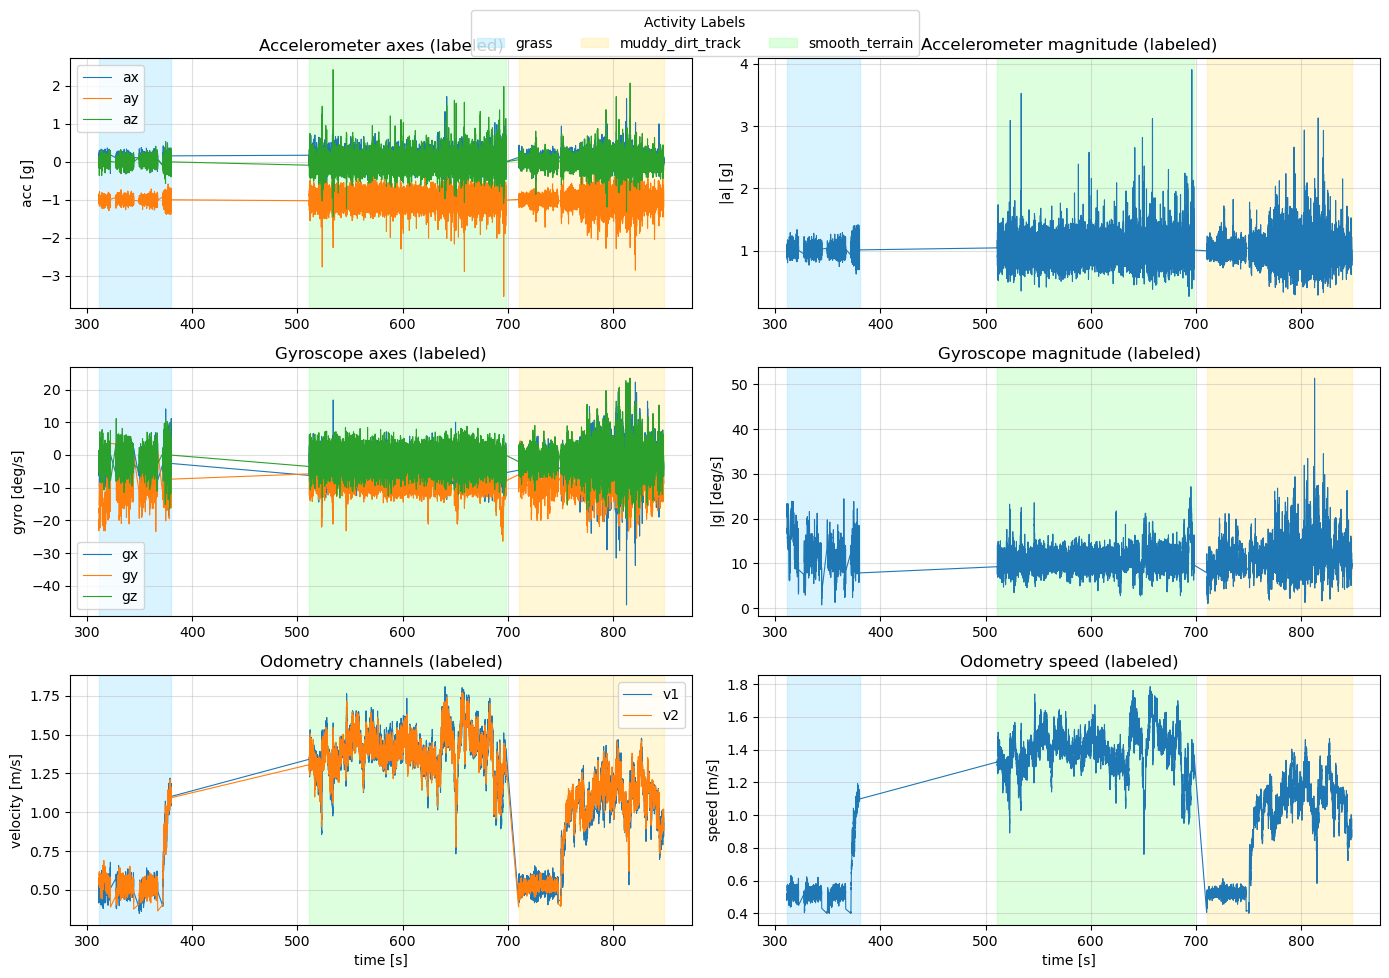

Plotting_labeled_acc for log_20260223_142511.490


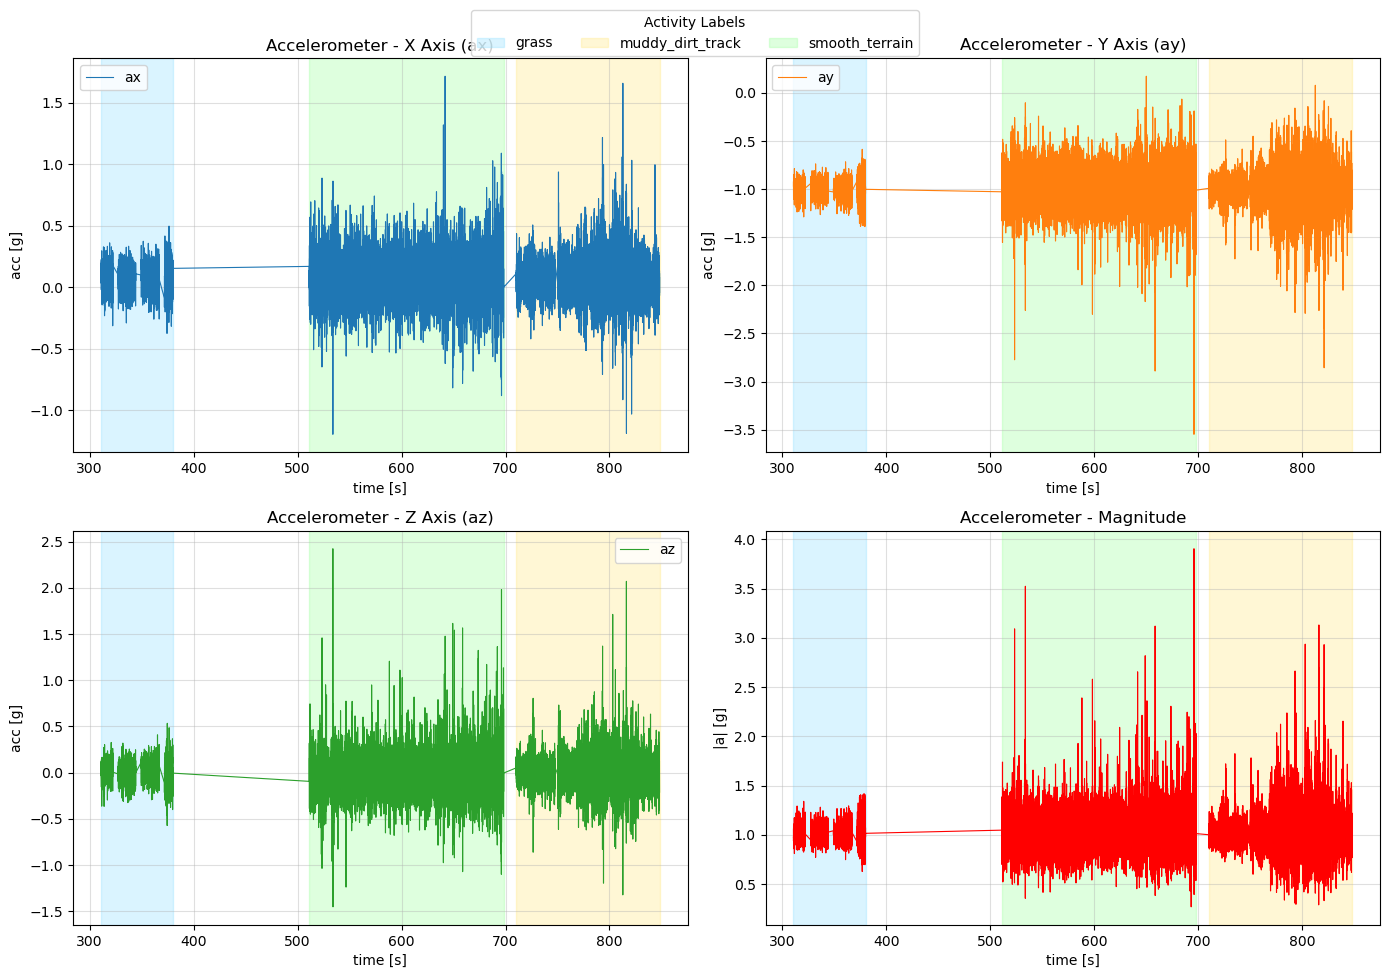

Plotting_labeled_gyro for log_20260223_142511.490


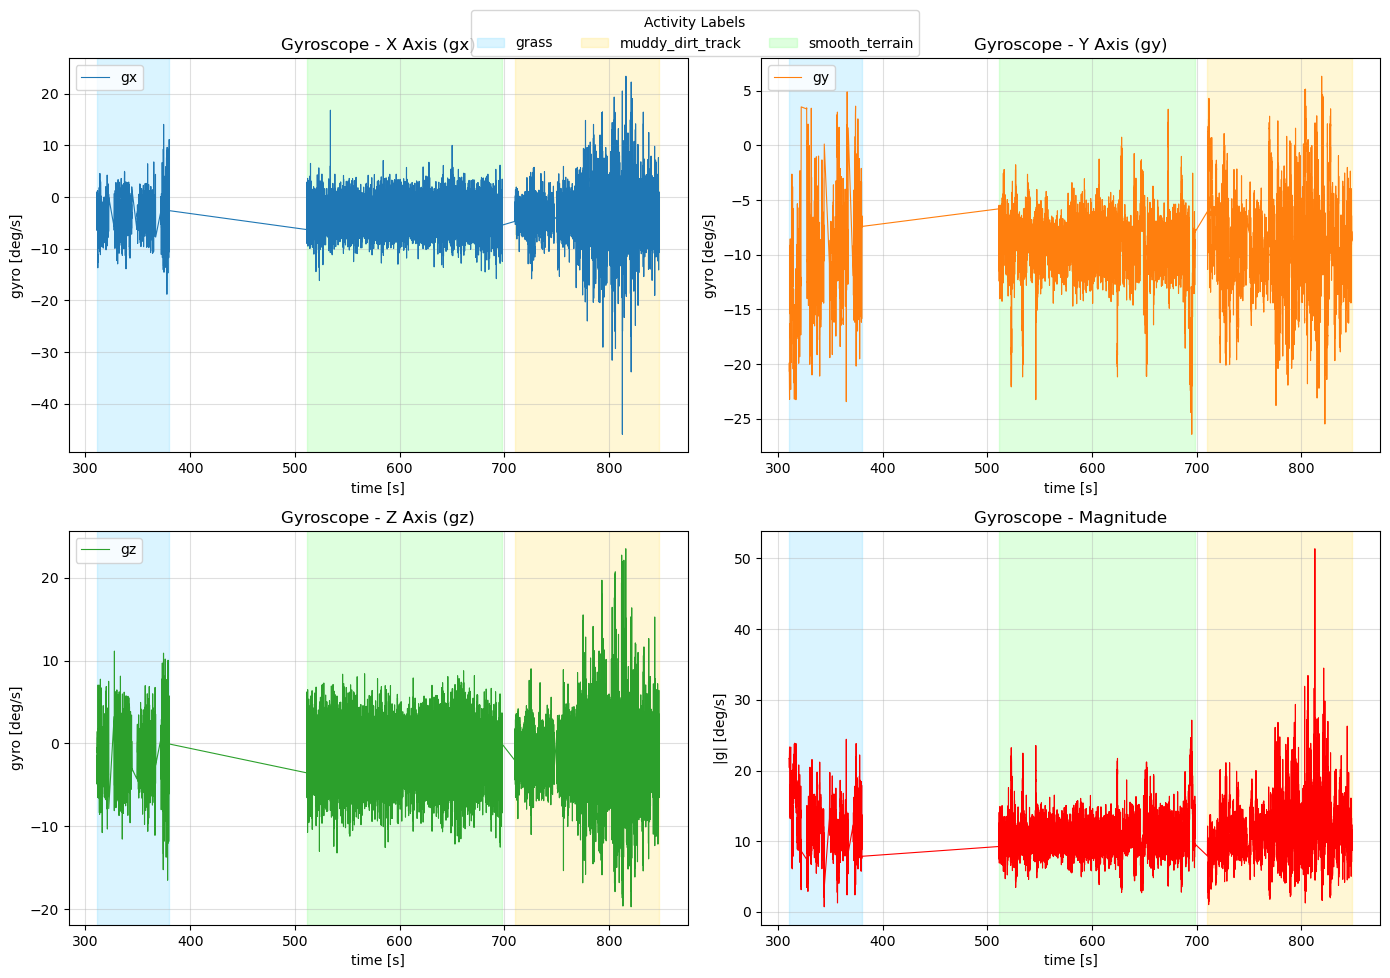

Plotting_labeled_odo for log_20260223_142511.490


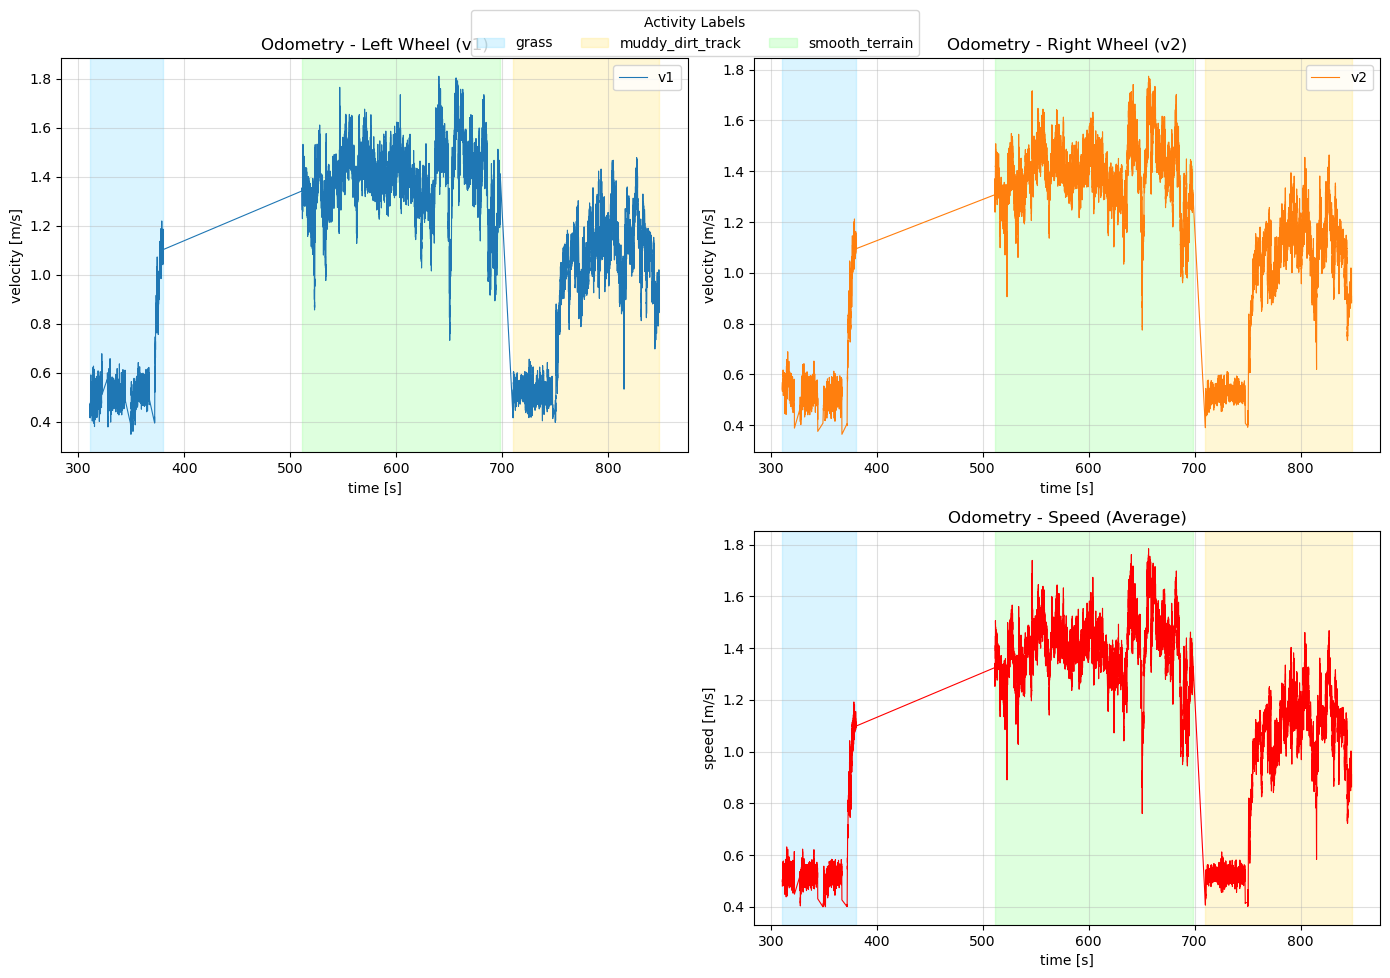


Plotting labeled sensors for log_20260226_102148.990...


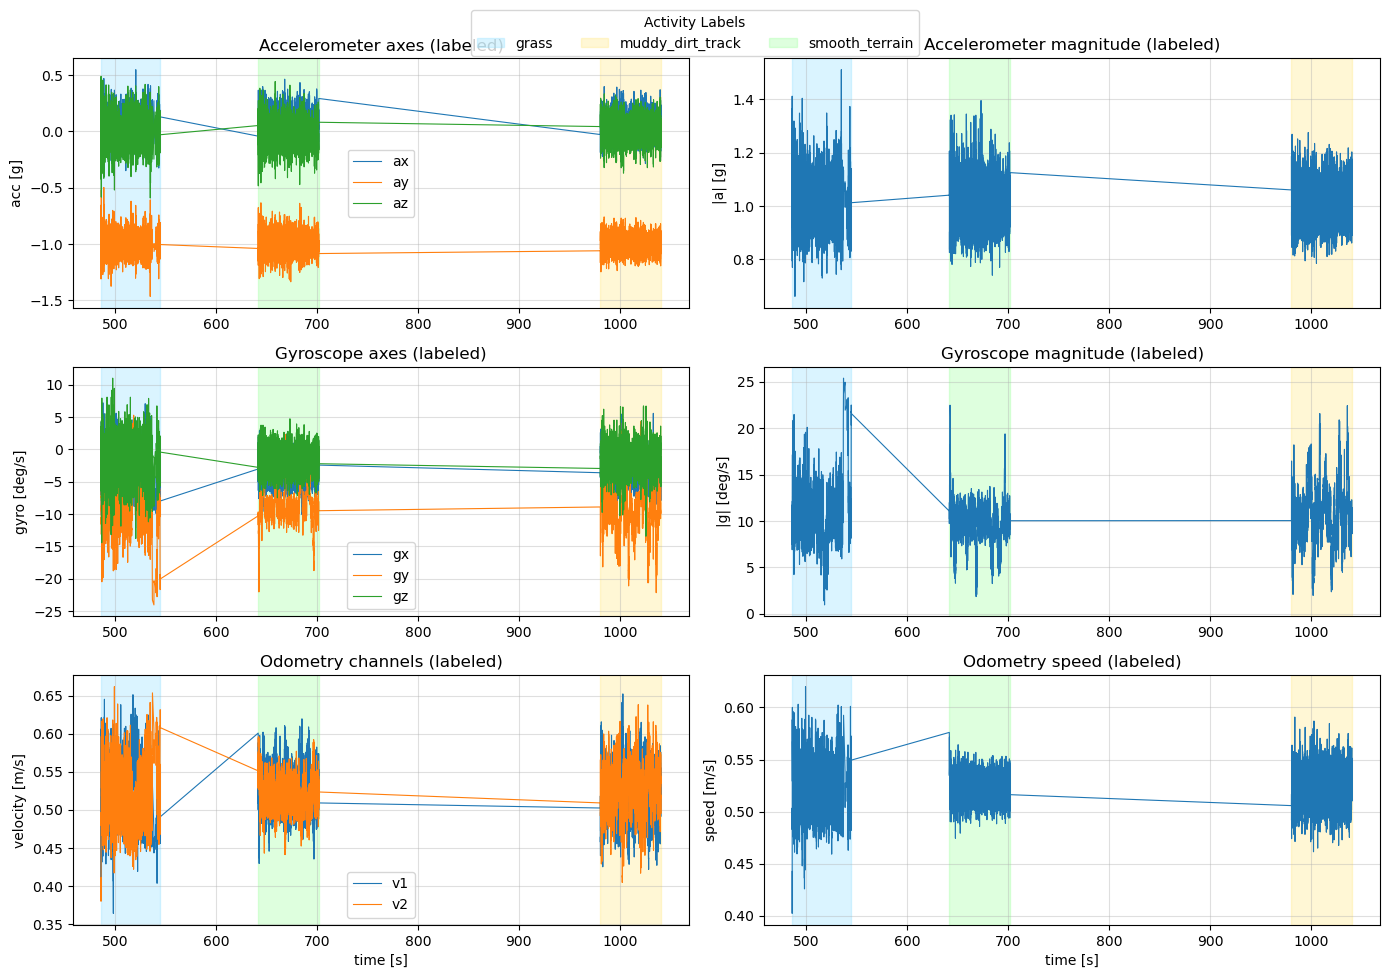

Plotting_labeled_acc for log_20260226_102148.990


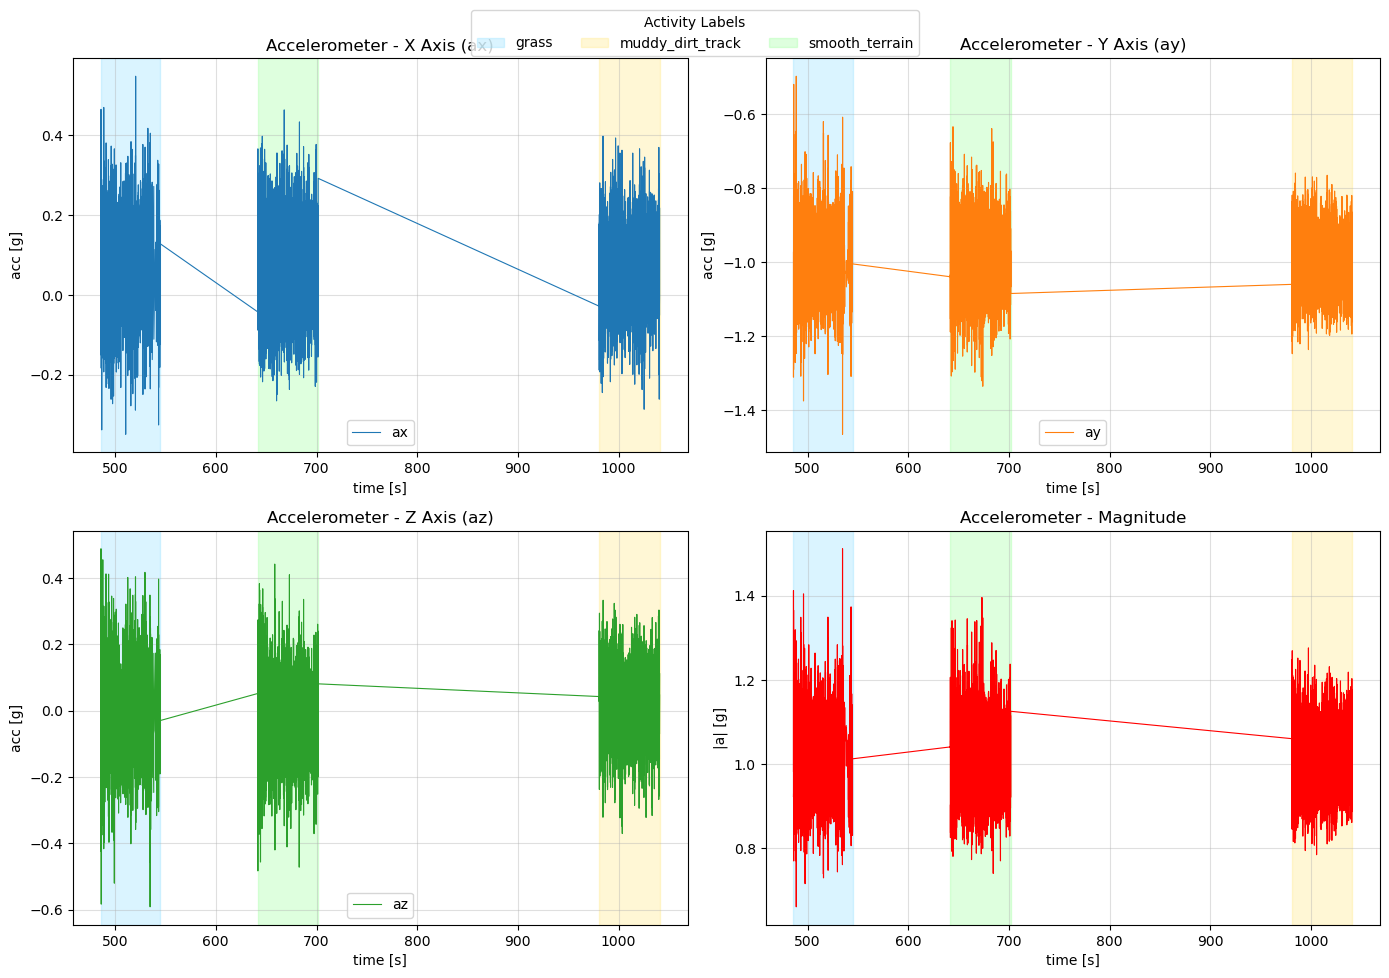

Plotting_labeled_gyro for log_20260226_102148.990


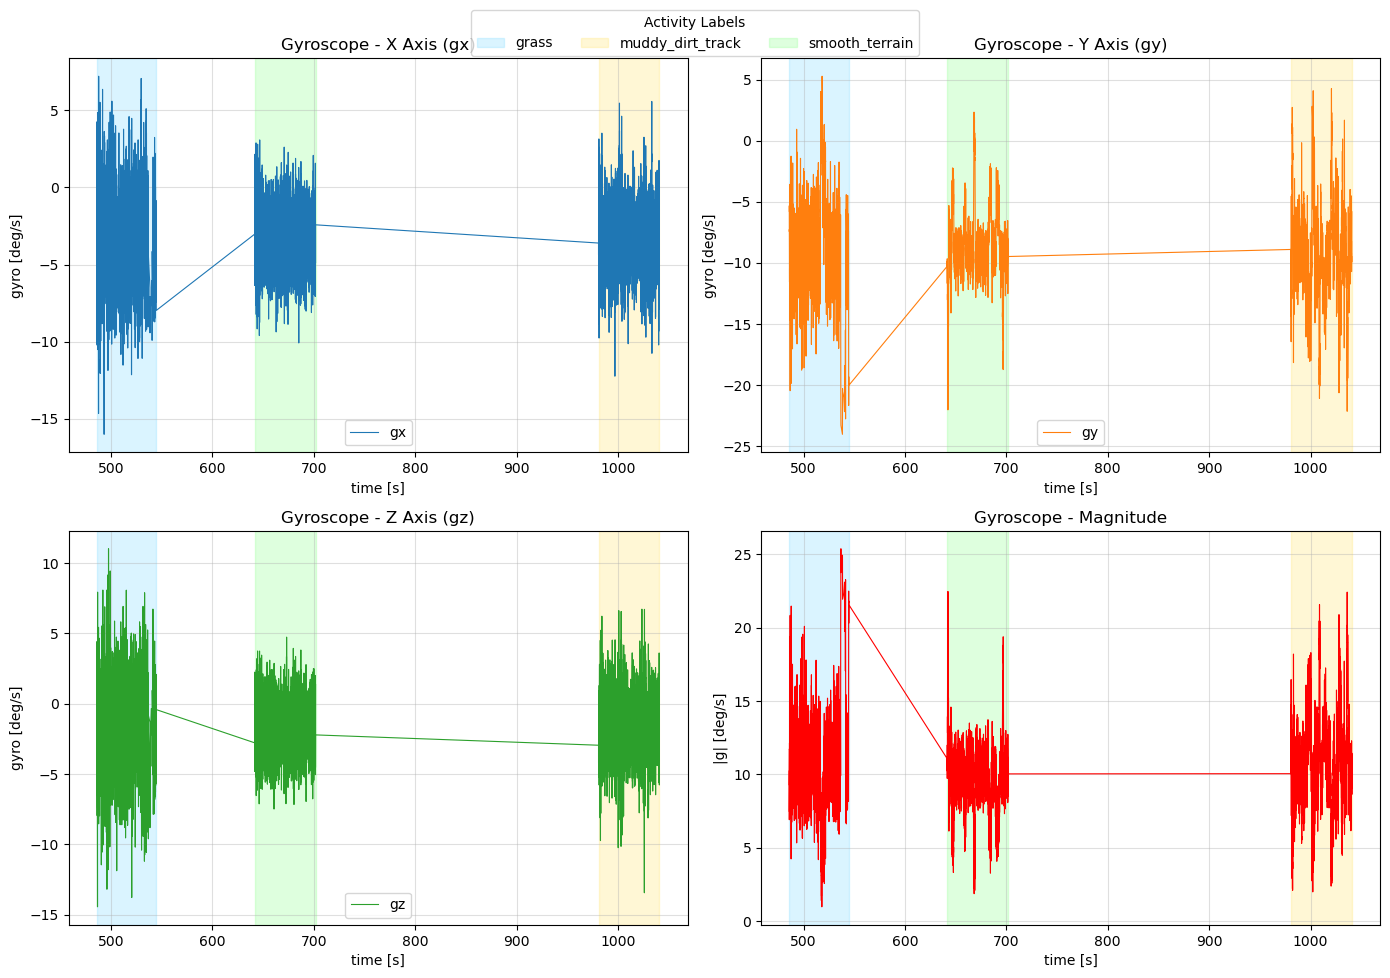

Plotting_labeled_odo for log_20260226_102148.990


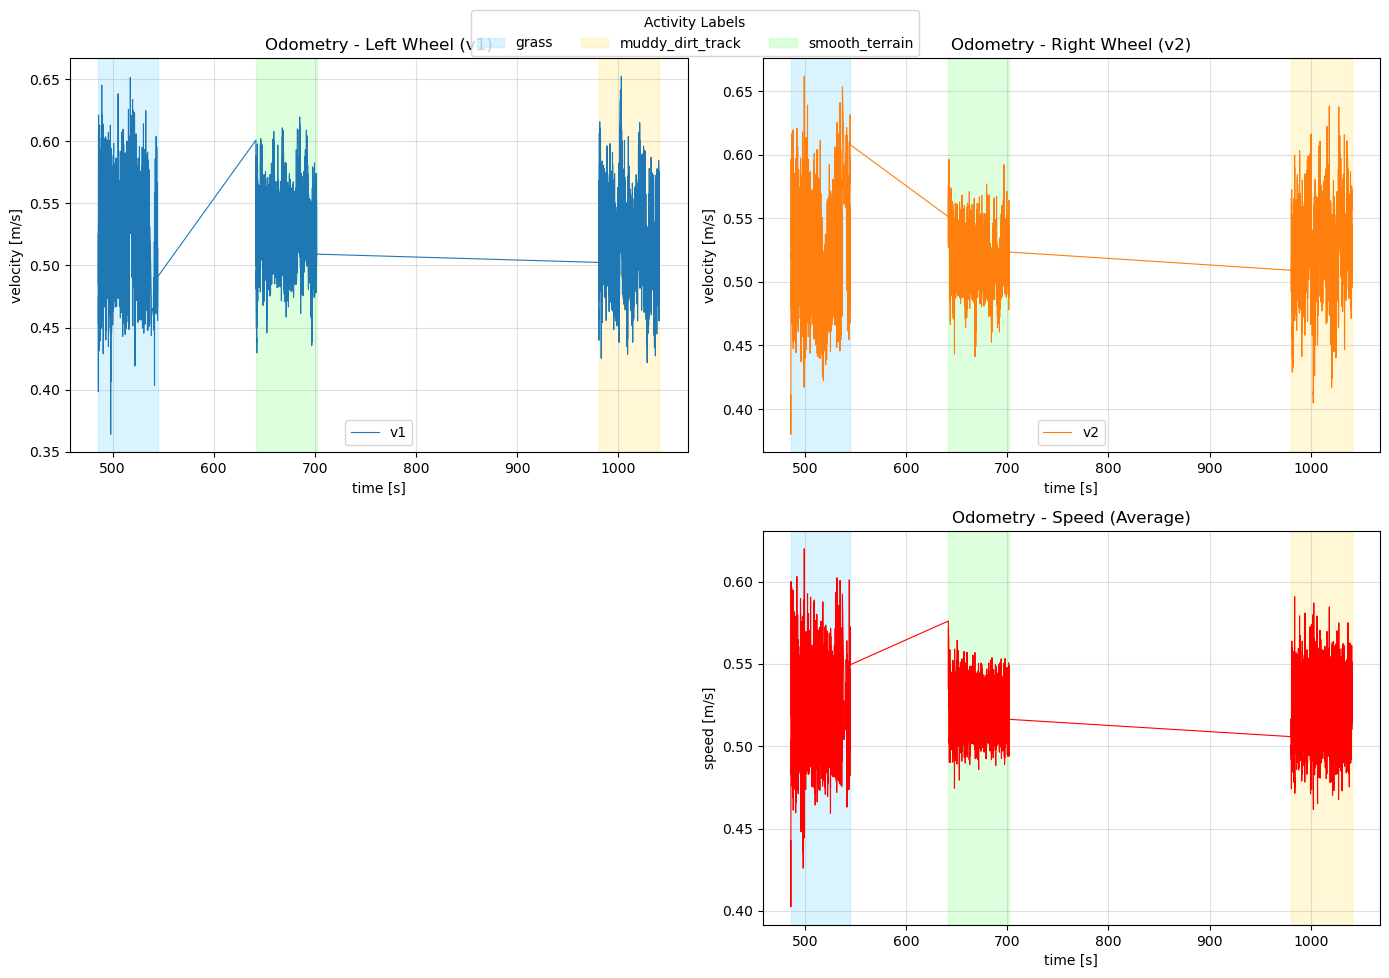

In [41]:
# Plotting after removing unlabeled samples (per run) not necessary to run every time but as a check
if labeled_df.empty:
    print("No labeled samples available to plot.")
else:
    for run_id in sorted(labeled_df['run_id'].unique()):
        run_df = labeled_df[labeled_df['run_id'] == run_id].copy()

        acc_labeled = run_df[['t', 't_rel', 'ax', 'ay', 'az', 'label']].copy()
        gyro_labeled = run_df[['t', 't_rel', 'gx', 'gy', 'gz', 'label']].copy()
        odo_labeled = run_df[['t', 't_rel', 'v1', 'v2', 'label']].copy()

        print(f"\nPlotting labeled sensors for {run_id}...")
        _ = plot_labeled_sensors(
            acc=acc_labeled,
            gyro=gyro_labeled,
            odo=odo_labeled,
            tcol='t_rel',
            show=True
        )

        print(f"Plotting_labeled_acc for {run_id}")
        plot_labeled_acc(acc_labeled, tcol='t_rel', show=True)
        print(f"Plotting_labeled_gyro for {run_id}")
        plot_labeled_gyro(gyro_labeled, tcol='t_rel', show=True)
        print(f"Plotting_labeled_odo for {run_id}")
        plot_labeled_odo(odo_labeled, tcol='t_rel', show=True)

In [42]:
# Save cleaned dataset
required_columns = [
    'run_id', 't', 't_rel',
    'ax', 'ay', 'az',
    'gx', 'gy', 'gz',
    'v1', 'v2',
    'label', 'net_speed', 'yaw_rate'
]
missing_columns = [col for col in required_columns if col not in labeled_df.columns]
if missing_columns:
    raise KeyError(f"Cannot save cleaned dataset. Missing required columns: {missing_columns}")

cleaned_dir = PROJECT_ROOT / "data" / "interim" / "cleaned"
cleaned_dir.mkdir(parents=True, exist_ok=True)
cleaned_path = cleaned_dir / "cleaned_dataset.csv"

labeled_df = labeled_df.sort_values(['run_id', 't_rel']).reset_index(drop=True)
labeled_df.to_csv(cleaned_path, index=False)

print(f"Saved cleaned dataset to: {cleaned_path}")
print(f"Shape: {labeled_df.shape}")
print(f"Columns: {list(labeled_df.columns)}")

Saved cleaned dataset to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/data/interim/cleaned/cleaned_dataset.csv
Shape: (53670, 14)
Columns: ['t', 't_rel', 'run_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'v1', 'v2', 'label', 'net_speed', 'yaw_rate']
